# TripletNet1 latent-space visualisation and metadata consistency

Run this notebook after `model1.ipynb` has finished training. It reruns only the latent-space / metadata analysis section.

If `TripletNet1_artist_latent_embeddings.csv` already exists, this notebook can load that CSV directly and does not need the `.pt` model checkpoint. If the latent CSV is missing, it reloads the trained checkpoint and re-encodes all artists.

The checkpoint saved by `model1.ipynb` is normally:

- from inside `code/`: `checkpoints/TripletNet1/TripletNet1_margin_0.10_fold_4_best.pt`
- from the project root: `code/checkpoints/TripletNet1/TripletNet1_margin_0.10_fold_4_best.pt`

If your checkpoint is somewhere else, edit `CHECKPOINT_PATH` in the checkpoint cell.

This notebook uses CPU `sklearn.manifold.TSNE` for t-SNE and plots all available artists by default.

In [1]:
# Install scikit-learn into the active Jupyter kernel if it is missing.
# Set this to False if you prefer to install it manually with: %pip install scikit-learn
INSTALL_MISSING_SKLEARN = True

# t-SNE uses sklearn on CPU. CPU_TSNE_MAX_POINTS=None means plot all available artists.
RUN_TSNE = True
USE_GPU_TSNE = False
CPU_TSNE_FALLBACK = True
TSNE_N_ITER = 1000
CPU_TSNE_MAX_POINTS = None

import importlib.util
import os
import subprocess
import sys

# Some hosted kernels set OMP_NUM_THREADS to an invalid value. libgomp reads it
# during sklearn/scipy import, so fix it before importing those packages.
for var in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    value = os.environ.get(var, "").strip()
    if not value.isdigit() or int(value) < 1:
        os.environ[var] = "1"

if importlib.util.find_spec("sklearn") is None:
    if not INSTALL_MISSING_SKLEARN:
        raise ModuleNotFoundError("scikit-learn is missing. Run `%pip install scikit-learn`, restart the kernel, then rerun this notebook.")
    print("scikit-learn is missing; installing into the current kernel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

CuMLTSNE = None
CUML_IMPORT_ERROR = None
if RUN_TSNE and USE_GPU_TSNE:
    try:
        from cuml.manifold import TSNE as CuMLTSNE
    except Exception as exc:
        CUML_IMPORT_ERROR = exc

print("scikit-learn is available.")
if RUN_TSNE:
    if CuMLTSNE is not None:
        print("RAPIDS cuML TSNE is available; t-SNE will run on GPU.")
    elif CPU_TSNE_FALLBACK:
        point_msg = "all available artists" if CPU_TSNE_MAX_POINTS is None else f"max {CPU_TSNE_MAX_POINTS} points per plot"
        print(f"t-SNE will run with sklearn on CPU using {point_msg}.")
    else:
        print("t-SNE is requested but no backend is enabled; it will be skipped.")
else:
    print("t-SNE is disabled. PCA, group similarity, and silhouette analysis will still run.")

scikit-learn is available.
t-SNE will run with sklearn on CPU using all available artists.


In [2]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

SEED = 3407
MODEL_NAME = "TripletNet1"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cwd = Path.cwd().resolve()
if (cwd / "model.py").exists():
    CODE_DIR = cwd
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd
    CODE_DIR = PROJECT_ROOT / "code"

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from dataset import process_artists
from model import build_model
from utils import set_seed

set_seed(SEED)

BASE_DIR = PROJECT_ROOT / "data" / "video_embeddings"
METADATA_DIR = PROJECT_ROOT / "data" / "metadata"

print(f"Project root: {PROJECT_ROOT}")
print(f"Code dir: {CODE_DIR}")
print(f"Device: {DEVICE}")

Project root: /root/autodl-tmp/thesis-artist-similarity
Code dir: /root/autodl-tmp/thesis-artist-similarity/code
Device: cuda


In [3]:
# Edit this if auto-discovery picks the wrong checkpoint.
CHECKPOINT_PATH: str | Path | None = None

# If a latent embedding CSV already exists, the notebook can reuse it instead of re-encoding all artists.
USE_CACHED_ARTIST_EMBEDDINGS = True
LATENT_CSV_PATH: str | Path | None = None

def dedupe_paths(paths: list[Path]) -> list[Path]:
    seen = set()
    out = []
    for path in paths:
        key = str(path.resolve()) if path.exists() else str(path)
        if key not in seen:
            seen.add(key)
            out.append(path)
    return out

def discover_checkpoint() -> Path:
    if CHECKPOINT_PATH is not None:
        path = Path(CHECKPOINT_PATH)
        path = path if path.is_absolute() else PROJECT_ROOT / path
        if not path.exists():
            raise FileNotFoundError(f"CHECKPOINT_PATH does not exist: {path}")
        return path

    preferred = [
        CODE_DIR / "checkpoints" / MODEL_NAME / "TripletNet1_margin_0.10_fold_4_best.pt",
        CODE_DIR / "checkpoints" / MODEL_NAME / "TripletNet1_margin_0.1_fold_4_best.pt",
        PROJECT_ROOT / "results" / "checkpoints" / "TripletNet1_margin_0.1_best.pt",
        PROJECT_ROOT / "results" / "checkpoints" / "TripletNet1_margin_0.10_best.pt",
    ]
    for path in preferred:
        if path.exists():
            return path

    candidates = []
    candidates.extend((CODE_DIR / "checkpoints" / MODEL_NAME).glob("*best.pt"))
    candidates.extend((PROJECT_ROOT / "results" / "checkpoints").glob("*TripletNet1*best.pt"))
    candidates = [path for path in dedupe_paths(list(candidates)) if path.exists()]
    if not candidates:
        expected = "\n".join(str(path) for path in preferred)
        raise FileNotFoundError(
            "No TripletNet1 checkpoint was found. Expected one of these paths, or set CHECKPOINT_PATH manually:\n"
            + expected
        )
    return max(candidates, key=lambda path: path.stat().st_mtime)

def discover_latent_csv(checkpoint_path: Path | None = None) -> Path | None:
    if LATENT_CSV_PATH is not None:
        path = Path(LATENT_CSV_PATH)
        path = path if path.is_absolute() else PROJECT_ROOT / path
        return path if path.exists() else None

    candidates = []
    if checkpoint_path is not None:
        candidates.append(checkpoint_path.parent / "analysis" / "TripletNet1_artist_latent_embeddings.csv")
    candidates.extend((CODE_DIR / "checkpoints" / MODEL_NAME / "analysis").glob("*artist_latent_embeddings.csv"))
    candidates.extend((PROJECT_ROOT / "results" / "checkpoints").glob("**/*artist_latent_embeddings.csv"))
    candidates = [path for path in dedupe_paths(list(candidates)) if path.exists()]
    return max(candidates, key=lambda path: path.stat().st_mtime) if candidates else None

checkpoint_path: Path | None = None
latent_csv = discover_latent_csv(None)

if USE_CACHED_ARTIST_EMBEDDINGS and latent_csv is not None:
    print(f"Loading cached artist embeddings: {latent_csv}")
    artist_embedding_df = pd.read_csv(latent_csv)
    if "artist_id" in artist_embedding_df.columns:
        artist_embedding_df["artist_id"] = artist_embedding_df["artist_id"].astype(str)
        artist_embedding_df = artist_embedding_df.set_index("artist_id")
else:
    checkpoint_path = discover_checkpoint()
    print(f"Loading checkpoint: {checkpoint_path}")

    if not BASE_DIR.exists():
        raise FileNotFoundError(f"Embedding directory does not exist: {BASE_DIR}")

    artist_tensors = process_artists(
        BASE_DIR,
        aggregation="stack",
        max_videos=10,
        num_frames=30,
        keep_most_common_shape=True,
    )
    if not artist_tensors:
        raise RuntimeError(f"No artist embeddings found under {BASE_DIR}")

    sample = next(iter(artist_tensors.values()))
    if sample.ndim != 3:
        raise ValueError(f"TripletNet1 latent notebook expects stacked artist tensors, got sample shape {tuple(sample.shape)}")

    model_kwargs = {
        "d_model": int(sample.shape[2]),
        "seq_len": int(sample.shape[1]),
        "max_videos": int(sample.shape[0]),
        "video_dropout_p": 0.0,
    }
    model = build_model(MODEL_NAME, **model_kwargs).to(DEVICE)
    state = torch.load(checkpoint_path, map_location=DEVICE)
    if isinstance(state, dict):
        for key in ("state_dict", "model_state_dict", "model"):
            if key in state and isinstance(state[key], dict):
                state = state[key]
                break
    if isinstance(state, dict) and any(str(key).startswith("module.") for key in state):
        state = {str(key).removeprefix("module."): value for key, value in state.items()}
    model.load_state_dict(state, strict=True)
    model.eval()

    @torch.inference_mode()
    def encode_artists(batch_size: int = 256) -> pd.DataFrame:
        artist_ids = sorted(map(str, artist_tensors.keys()))
        chunks = []
        for start in range(0, len(artist_ids), batch_size):
            batch_ids = artist_ids[start:start + batch_size]
            batch = torch.stack([artist_tensors[artist_id].float() for artist_id in batch_ids], dim=0).to(DEVICE)
            encoded = model.forward_once(batch).detach().cpu().float()
            encoded = F.normalize(encoded, dim=1, eps=1e-8)
            chunks.append(encoded.numpy())
        matrix = np.vstack(chunks)
        columns = [f"z_{idx:03d}" for idx in range(matrix.shape[1])]
        return pd.DataFrame(matrix, index=artist_ids, columns=columns)

    artist_embedding_df = encode_artists(batch_size=256)
    output_dir = checkpoint_path.parent / "analysis" / "latent_metadata"
    output_dir.mkdir(parents=True, exist_ok=True)
    cached_out = output_dir / "TripletNet1_artist_latent_embeddings.csv"
    artist_embedding_df.reset_index(names="artist_id").to_csv(cached_out, index=False)
    print(f"Saved artist latent embeddings: {cached_out}")

if checkpoint_path is None:
    try:
        checkpoint_path = discover_checkpoint()
    except FileNotFoundError:
        checkpoint_path = None

OUTPUT_DIR = (checkpoint_path.parent / "analysis" / "latent_metadata") if checkpoint_path is not None else (CODE_DIR / "latent_metadata_outputs" / MODEL_NAME)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

feature_cols = [col for col in artist_embedding_df.columns if str(col).startswith("z_")]
print(f"Artist embeddings: {len(artist_embedding_df)} artists, {len(feature_cols)} dimensions")
print(f"Output dir: {OUTPUT_DIR}")

Loading cached artist embeddings: /root/autodl-tmp/thesis-artist-similarity/code/checkpoints/TripletNet1/analysis/TripletNet1_artist_latent_embeddings.csv
Artist embeddings: 3892 artists, 256 dimensions
Output dir: /root/autodl-tmp/thesis-artist-similarity/code/checkpoints/TripletNet1/analysis/latent_metadata


In [4]:
def load_artist_metadata() -> pd.DataFrame:
    candidate_paths = [
        METADATA_DIR / "artists_genre_country.csv",
        METADATA_DIR / "artists_genre_country_major_genres.csv",
        METADATA_DIR / "artists.csv",
        METADATA_DIR / "artists_metadata.csv",
        METADATA_DIR / "metadata.csv",
    ]
    for path in candidate_paths:
        if not path.exists():
            continue
        df = pd.read_csv(path)
        df.columns = [str(col).strip() for col in df.columns]
        lower_map = {col.lower(): col for col in df.columns}
        id_col = None
        for candidate in ["musicbrainz_id", "artist_id", "id", "mbid"]:
            if candidate in lower_map:
                id_col = lower_map[candidate]
                break
        if id_col is None:
            print(f"Skipping metadata file without artist id column: {path}")
            continue
        df = df.rename(columns={id_col: "artist_id"})
        df["artist_id"] = df["artist_id"].astype(str)
        df["metadata_source"] = str(path)
        return df
    return pd.DataFrame()

def infer_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    lower_map = {col.lower(): col for col in df.columns}
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    return None

artist_metadata_df = load_artist_metadata()
if artist_metadata_df.empty:
    raise FileNotFoundError(f"No usable metadata file found under {METADATA_DIR}")

# Add artist names from artists.csv when the selected metadata file does not include them.
artists_csv = METADATA_DIR / "artists.csv"
if artists_csv.exists() and "name" not in artist_metadata_df.columns:
    names_df = pd.read_csv(artists_csv, usecols=lambda col: str(col).lower() in {"musicbrainz_id", "artist_id", "id", "mbid", "name", "artist", "artist_name"})
    names_df.columns = [str(col).strip() for col in names_df.columns]
    name_id_col = infer_column(names_df, ["musicbrainz_id", "artist_id", "id", "mbid"])
    name_col = infer_column(names_df, ["name", "artist", "artist_name"])
    if name_id_col is not None and name_col is not None:
        names_df = names_df.rename(columns={name_id_col: "artist_id", name_col: "name"})
        names_df["artist_id"] = names_df["artist_id"].astype(str)
        artist_metadata_df = artist_metadata_df.merge(names_df[["artist_id", "name"]], on="artist_id", how="left")

country_col = infer_column(artist_metadata_df, ["country", "nationality", "artist_country"])
genre_col = infer_column(artist_metadata_df, ["genre", "genres", "general_genre", "main_genre", "music_genre"])
broad_genre_col = infer_column(artist_metadata_df, ["broad_genre", "major_genre", "macro_genre"])
name_col = infer_column(artist_metadata_df, ["name", "artist", "artist_name"])

# Build a defragmented frame before merging; this avoids a Pandas fragmentation warning
# when artist_embedding_df was loaded from a wide latent CSV.
embedding_for_merge = pd.DataFrame(
    artist_embedding_df.to_numpy(copy=True),
    columns=list(artist_embedding_df.columns),
)
embedding_for_merge.insert(0, "artist_id", artist_embedding_df.index.astype(str).to_numpy())
metadata_embedding_df = embedding_for_merge.merge(artist_metadata_df, on="artist_id", how="left")
metadata_embedding_df.to_csv(OUTPUT_DIR / "TripletNet1_latent_with_metadata.csv", index=False)

print(f"Metadata source: {artist_metadata_df['metadata_source'].iloc[0]}")
print(f"Matched metadata rows: {metadata_embedding_df['metadata_source'].notna().sum()} / {len(metadata_embedding_df)}")
print(f"country_col={country_col}, broad_genre_col={broad_genre_col}, genre_col={genre_col}, name_col={name_col}")
display(metadata_embedding_df.head())

Metadata source: /root/autodl-tmp/thesis-artist-similarity/data/metadata/artists_genre_country.csv
Matched metadata rows: 3892 / 3892
country_col=country, broad_genre_col=broad_genre, genre_col=genre, name_col=name


,artist_id,z_000,z_001,z_002,z_003,z_004,z_005,z_006,z_007,z_008,...,z_251,z_252,z_253,z_254,z_255,genre,broad_genre,country,metadata_source,name
0,0004537a-4b12-43eb-a023-04009e738d2e,-0.017455,-0.031888,-0.017882,-0.010144,-0.064266,0.036901,-0.003949,-0.020363,-0.065508,...,-0.011083,0.033313,-0.021747,-0.054278,-0.081205,vocal,others,USA,/root/autodl-tmp/thesis-artist-similarity/data...,Ultra Naté
1,0011f816-f0a8-4603-b82d-6f021d214672,0.032158,-0.108760,-0.001930,0.054092,-0.058378,0.090765,-0.016850,-0.098116,-0.028784,...,-0.116117,-0.048762,-0.013802,-0.043789,-0.004349,jazz,jazz,USA,/root/autodl-tmp/thesis-artist-similarity/data...,Rick Wade
2,0039c7ae-e1a7-4a7d-9b49-0cbc716821a6,-0.013863,0.015946,-0.034570,0.000658,0.036828,0.051640,-0.021339,-0.052132,0.042520,...,0.013563,-0.051931,-0.074990,-0.073236,0.120638,rock,rock,USA,/root/autodl-tmp/thesis-artist-similarity/data...,Death Cab for Cutie
3,003f3a74-7595-4da7-b46b-19a8f8e9a1b5,-0.003316,0.102871,-0.069735,-0.003173,-0.110508,-0.029686,-0.030198,-0.081769,0.022072,...,0.089918,-0.012232,-0.002861,-0.071127,-0.038539,pop,pop,Italy,/root/autodl-tmp/thesis-artist-similarity/data...,Ornella Vanoni
4,00467da8-2a92-498f-8b10-a80889bcded7,0.003430,-0.016791,-0.027103,0.075782,0.011879,0.046317,0.023414,0.020069,-0.052222,...,0.071462,-0.012253,-0.049825,-0.009486,0.101949,rock,rock,UK,/root/autodl-tmp/thesis-artist-similarity/data...,The Horrors


In [5]:
def _feature_matrix(df: pd.DataFrame) -> np.ndarray:
    cols = [col for col in df.columns if str(col).startswith("z_")]
    x = df[cols].to_numpy(dtype=np.float32)
    return x / np.maximum(np.linalg.norm(x, axis=1, keepdims=True), 1e-8)

def _as_numpy(coords) -> np.ndarray:
    if hasattr(coords, "to_numpy"):
        coords = coords.to_numpy()
    elif hasattr(coords, "get"):
        coords = coords.get()
    return np.asarray(coords, dtype=np.float32)

def run_gpu_tsne(x: np.ndarray, perplexity: int) -> np.ndarray:
    if CuMLTSNE is None:
        raise RuntimeError(f"RAPIDS cuML TSNE is unavailable: {CUML_IMPORT_ERROR}")

    # Use Euclidean on L2-normalized embeddings. For normalized vectors this is
    # monotonic with cosine distance and is better supported by GPU t-SNE APIs.
    base_kwargs = dict(
        n_components=2,
        perplexity=perplexity,
        random_state=SEED,
        learning_rate=200.0,
        metric="euclidean",
    )
    attempts = [
        dict(base_kwargs, max_iter=TSNE_N_ITER, init="pca"),
        dict(base_kwargs, n_iter=TSNE_N_ITER, init="pca"),
        dict(base_kwargs, max_iter=TSNE_N_ITER),
        dict(base_kwargs, n_iter=TSNE_N_ITER),
    ]
    last_error = None
    for kwargs in attempts:
        try:
            return _as_numpy(CuMLTSNE(**kwargs).fit_transform(x.astype(np.float32, copy=False)))
        except TypeError as exc:
            last_error = exc
    raise last_error if last_error is not None else RuntimeError("cuML TSNE failed")

def plot_latent_projection(label_col: str | None, method: str = "tsne", max_points: int | None = None, top_n: int = 12) -> pd.DataFrame | None:
    if label_col is None or label_col not in metadata_embedding_df.columns:
        print(f"No usable label column for {method.upper()} plot.")
        return None

    plot_df = metadata_embedding_df.dropna(subset=[label_col]).copy()
    plot_df = plot_df[plot_df[label_col].astype(str).str.strip().ne("")]
    if plot_df.empty:
        print(f"No non-null labels in column {label_col}.")
        return None
    if max_points is not None and len(plot_df) > max_points:
        print(f"Sampling {max_points} / {len(plot_df)} artists for {method.upper()} by {label_col}.")
        plot_df = plot_df.sample(max_points, random_state=SEED).copy()
    else:
        print(f"Using all {len(plot_df)} artists for {method.upper()} by {label_col}.")

    x = _feature_matrix(plot_df)
    if method == "pca":
        coords = PCA(n_components=2, random_state=SEED).fit_transform(x)
    elif method == "tsne":
        perplexity = min(40, max(5, (len(plot_df) - 1) // 3))
        if not RUN_TSNE:
            print(f"TSNE skipped for {label_col}: RUN_TSNE=False.")
            return None
        if USE_GPU_TSNE and CuMLTSNE is not None:
            print(f"Running GPU t-SNE with cuML for {label_col}: n={len(plot_df)}, perplexity={perplexity}")
            coords = run_gpu_tsne(x, perplexity)
        elif CPU_TSNE_FALLBACK:
            print(f"Running CPU sklearn t-SNE for {label_col}: n={len(plot_df)}, perplexity={perplexity}")
            kwargs = dict(n_components=2, random_state=SEED, metric="cosine", init="pca", perplexity=perplexity, learning_rate="auto")
            try:
                coords = TSNE(max_iter=TSNE_N_ITER, **kwargs).fit_transform(x)
            except TypeError:
                coords = TSNE(n_iter=TSNE_N_ITER, **kwargs).fit_transform(x)
        else:
            print(
                f"TSNE skipped for {label_col}: sklearn TSNE is CPU-only and RAPIDS cuML is not available. "
                "Install cuML or set CPU_TSNE_FALLBACK=True."
            )
            return None
    else:
        raise ValueError("method must be 'pca' or 'tsne'")

    plot_df["dim_1"] = coords[:, 0]
    plot_df["dim_2"] = coords[:, 1]

    labels = plot_df[label_col].astype(str).fillna("Unknown")
    top_labels = labels.value_counts().head(top_n).index.tolist()
    plot_df["plot_label"] = np.where(labels.isin(top_labels), labels, "Other")

    fig, ax = plt.subplots(figsize=(10, 7))
    for label, group in plot_df.groupby("plot_label"):
        ax.scatter(group["dim_1"], group["dim_2"], s=12, alpha=0.75, label=label)
    ax.set_title(f"{MODEL_NAME}: {method.upper()} latent space by {label_col}")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.grid(True, alpha=0.2)
    ax.legend(markerscale=2, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    stem = f"TripletNet1_{method}_{label_col}".replace(" ", "_")
    fig.savefig(OUTPUT_DIR / f"{stem}.png", dpi=180, bbox_inches="tight")
    plot_df.to_csv(OUTPUT_DIR / f"{stem}.csv", index=False)
    plt.show()
    return plot_df

def group_similarity_summary(label_col: str | None, min_group_size: int = 5, max_pairs: int = 20000) -> pd.DataFrame:
    if label_col is None or label_col not in metadata_embedding_df.columns:
        return pd.DataFrame()
    df = metadata_embedding_df.dropna(subset=[label_col]).copy()
    df = df[df[label_col].astype(str).str.strip().ne("")]
    if df.empty:
        return pd.DataFrame()
    matrix = _feature_matrix(df)
    labels = df[label_col].astype(str).to_numpy()
    rng = np.random.default_rng(SEED)
    rows = []
    for label in sorted(pd.Series(labels).dropna().unique()):
        idx = np.flatnonzero(labels == label)
        other_idx = np.flatnonzero(labels != label)
        if len(idx) < min_group_size or len(other_idx) == 0:
            continue
        n_possible = len(idx) * (len(idx) - 1) // 2
        n_pairs = min(max_pairs, n_possible)
        if n_pairs <= 0:
            continue
        i = rng.choice(idx, size=n_pairs, replace=True)
        j = rng.choice(idx, size=n_pairs, replace=True)
        keep = i != j
        i, j = i[keep], j[keep]
        if len(i) == 0:
            continue
        intra = np.sum(matrix[i] * matrix[j], axis=1)
        inter_i = rng.choice(idx, size=len(i), replace=True)
        inter_j = rng.choice(other_idx, size=len(i), replace=True)
        inter = np.sum(matrix[inter_i] * matrix[inter_j], axis=1)
        rows.append({
            "label_column": label_col,
            "label": label,
            "n_artists": int(len(idx)),
            "mean_intra_similarity": float(np.mean(intra)),
            "std_intra_similarity": float(np.std(intra)),
            "mean_inter_similarity": float(np.mean(inter)),
            "std_inter_similarity": float(np.std(inter)),
            "intra_minus_inter": float(np.mean(intra) - np.mean(inter)),
        })
    return pd.DataFrame(rows).sort_values("intra_minus_inter", ascending=False).reset_index(drop=True)

def silhouette_summary(label_col: str | None, min_group_size: int = 5, max_points: int = 2500) -> dict[str, float | str | int] | None:
    if label_col is None or label_col not in metadata_embedding_df.columns:
        return None
    df = metadata_embedding_df.dropna(subset=[label_col]).copy()
    df = df[df[label_col].astype(str).str.strip().ne("")]
    counts = df[label_col].astype(str).value_counts()
    valid_labels = counts[counts >= min_group_size].index
    df = df[df[label_col].astype(str).isin(valid_labels)].copy()
    if df[label_col].nunique() < 2 or len(df) <= df[label_col].nunique():
        return None
    if len(df) > max_points:
        df = df.sample(max_points, random_state=SEED).copy()
    x = _feature_matrix(df)
    labels = df[label_col].astype(str).to_numpy()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        score = silhouette_score(x, labels, metric="cosine")
    return {
        "label_column": label_col,
        "n_artists": int(len(df)),
        "n_labels": int(pd.Series(labels).nunique()),
        "silhouette_cosine": float(score),
    }

Running latent-space analysis for labels: ['country', 'broad_genre', 'genre']
Using all 3858 artists for PCA by country.


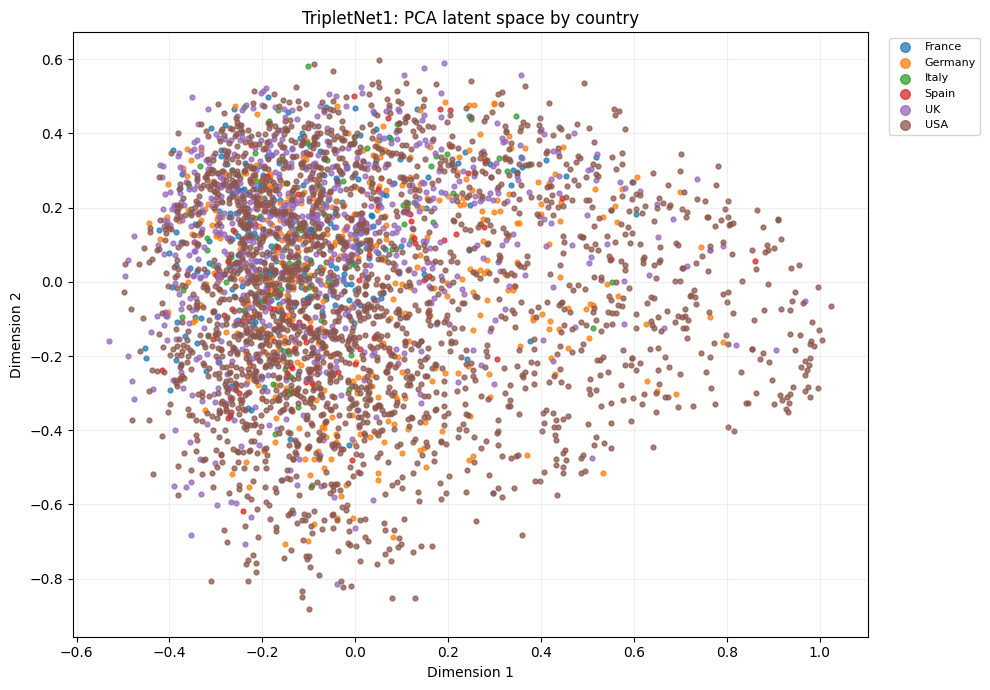

Using all 3858 artists for TSNE by country.
Running CPU sklearn t-SNE for country: n=3858, perplexity=40


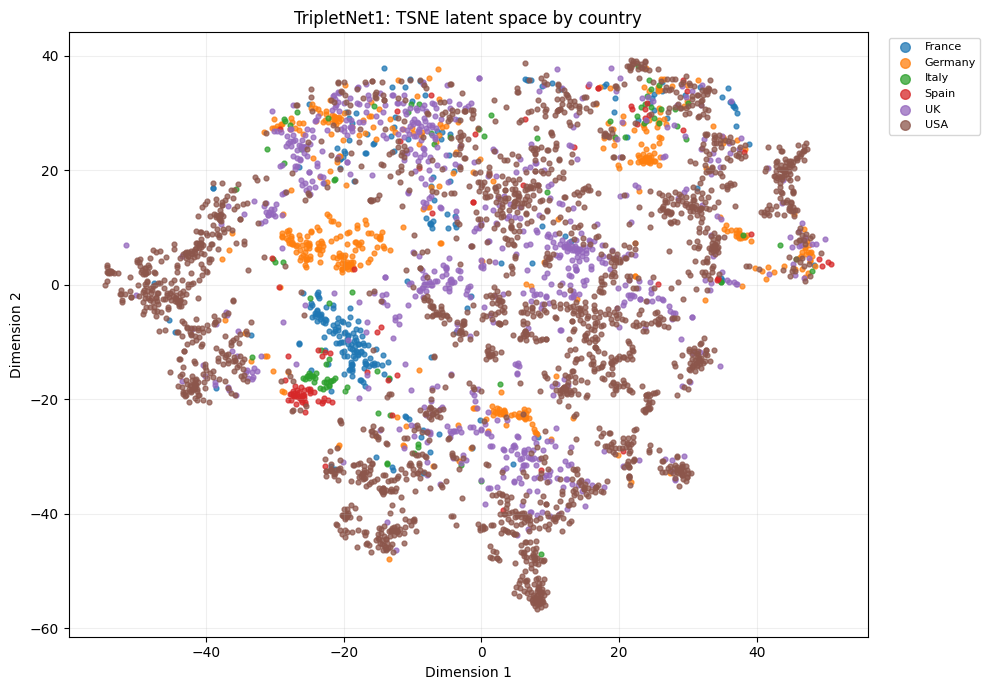

Using all 3892 artists for PCA by broad_genre.


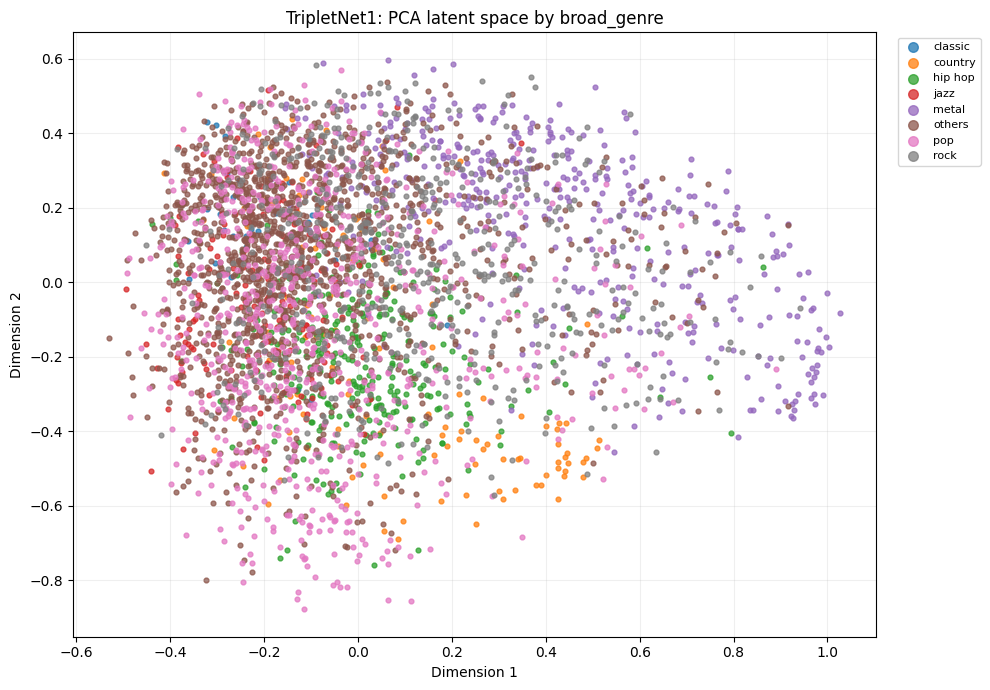

Using all 3892 artists for TSNE by broad_genre.
Running CPU sklearn t-SNE for broad_genre: n=3892, perplexity=40


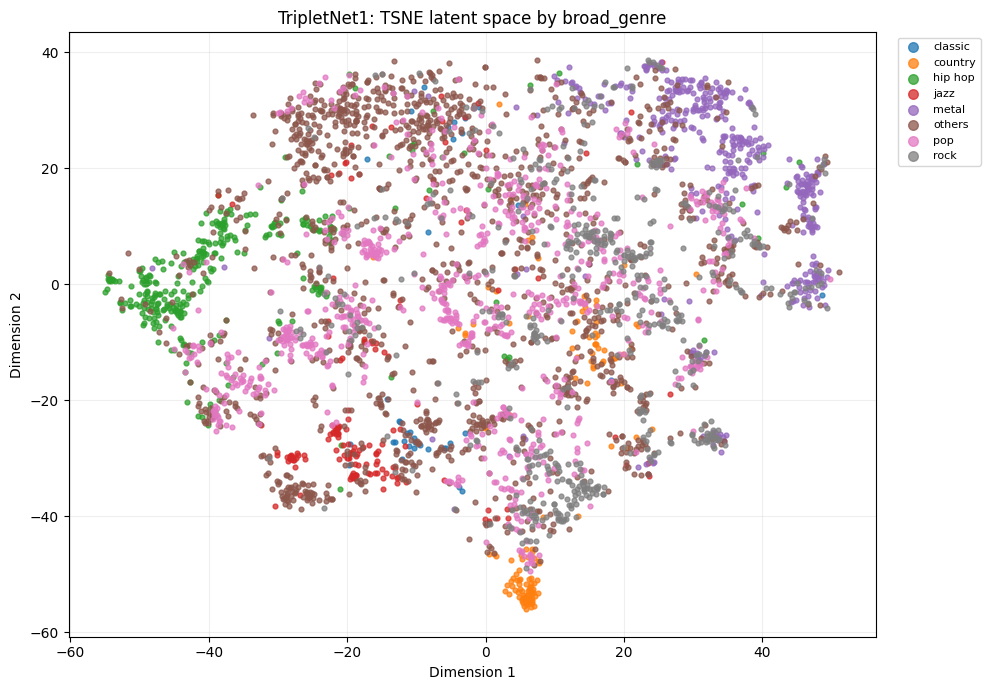

Using all 3860 artists for PCA by genre.


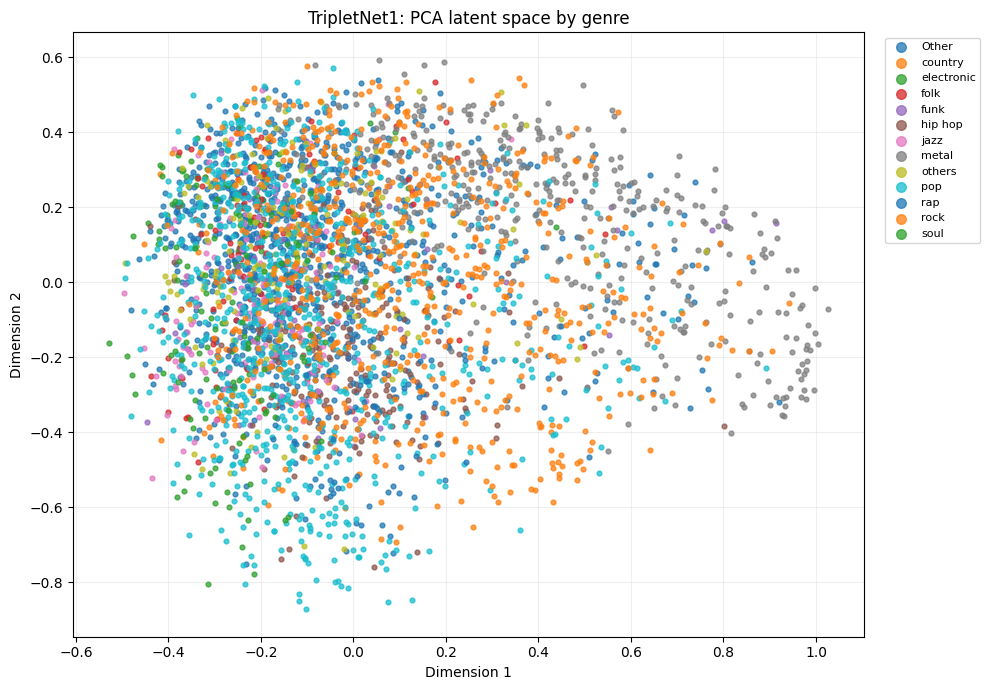

Using all 3860 artists for TSNE by genre.
Running CPU sklearn t-SNE for genre: n=3860, perplexity=40


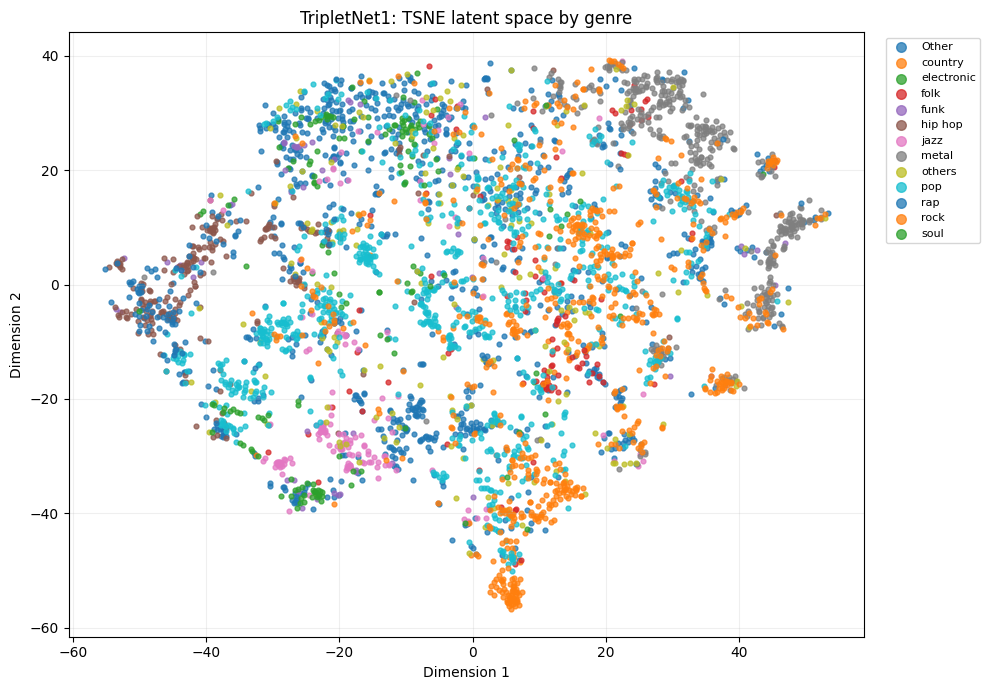


Group similarity by country


,label_column,label,n_artists,mean_intra_similarity,std_intra_similarity,mean_inter_similarity,std_inter_similarity,intra_minus_inter
0,country,Spain,93,0.290868,0.228548,0.062754,0.175182,0.228114
1,country,France,247,0.286152,0.205708,0.083929,0.182985,0.202223
2,country,Italy,99,0.230581,0.216485,0.083744,0.187780,0.146836
3,country,Germany,437,0.177367,0.225507,0.039378,0.190669,0.137989
4,country,UK,770,0.163893,0.213828,0.060485,0.204705,0.103408
5,country,USA,2212,0.040115,0.228897,0.033163,0.192600,0.006953



Group similarity by broad_genre


,label_column,label,n_artists,mean_intra_similarity,std_intra_similarity,mean_inter_similarity,std_inter_similarity,intra_minus_inter
0,broad_genre,classic,36,0.371293,0.184629,0.090200,0.194089,0.281093
1,broad_genre,country,131,0.260860,0.334294,-0.013388,0.195461,0.274248
2,broad_genre,metal,440,0.219342,0.285167,-0.022549,0.205107,0.241891
3,broad_genre,hip hop,323,0.263092,0.219535,0.025778,0.172142,0.237314
4,broad_genre,jazz,159,0.303941,0.209316,0.069876,0.183046,0.234065
5,broad_genre,others,1444,0.129276,0.198468,0.052692,0.196323,0.076585
6,broad_genre,pop,788,0.100980,0.222405,0.040525,0.206011,0.060455
7,broad_genre,rock,571,0.080286,0.252106,0.030514,0.205973,0.049773



Group similarity by genre


,label_column,label,n_artists,mean_intra_similarity,std_intra_similarity,mean_inter_similarity,std_inter_similarity,intra_minus_inter
0,genre,neue deutsche harte,5,0.786200,0.069157,-0.081821,0.127570,0.868021
1,genre,progressive house,5,0.762053,0.071943,0.022210,0.189041,0.739843
2,genre,jam band,8,0.707510,0.099979,-0.000463,0.150510,0.707972
3,genre,talent show,5,0.649273,0.091400,-0.021342,0.224093,0.670614
4,genre,chiptune,5,0.805503,0.042139,0.142552,0.088260,0.662951
5,genre,nouvelle chanson francaise,6,0.730840,0.102020,0.083996,0.192261,0.646844
6,genre,acid house,5,0.644166,0.117983,0.016261,0.110317,0.627905
7,genre,emo,5,0.726462,0.239418,0.104651,0.179714,0.621812
8,genre,brostep,6,0.723826,0.109559,0.121221,0.169137,0.602606
9,genre,deep euro house,5,0.711812,0.053117,0.110245,0.194494,0.601567



Silhouette summary


,label_column,n_artists,n_labels,silhouette_cosine
0,country,2500,6,-0.023250
1,broad_genre,2500,8,-0.020109
2,genre,2500,60,-0.266220


Done. Files saved under: /root/autodl-tmp/thesis-artist-similarity/code/checkpoints/TripletNet1/analysis/latent_metadata


In [6]:
label_columns = [col for col in [country_col, broad_genre_col, genre_col] if col is not None]
label_columns = list(dict.fromkeys(label_columns))
print(f"Running latent-space analysis for labels: {label_columns}")

projection_results = {}
for label_col in label_columns:
    projection_results[(label_col, "pca")] = plot_latent_projection(label_col, method="pca")
    projection_results[(label_col, "tsne")] = plot_latent_projection(label_col, method="tsne")

similarity_tables = []
for label_col in label_columns:
    table = group_similarity_summary(label_col)
    if not table.empty:
        table.to_csv(OUTPUT_DIR / f"TripletNet1_group_similarity_{label_col}.csv", index=False)
        print(f"\nGroup similarity by {label_col}")
        display(table.head(30))
        similarity_tables.append(table)

silhouette_rows = []
for label_col in label_columns:
    row = silhouette_summary(label_col)
    if row is not None:
        silhouette_rows.append(row)

silhouette_df = pd.DataFrame(silhouette_rows)
if not silhouette_df.empty:
    silhouette_df.to_csv(OUTPUT_DIR / "TripletNet1_silhouette_summary.csv", index=False)
    print("\nSilhouette summary")
    display(silhouette_df)

print(f"Done. Files saved under: {OUTPUT_DIR}")